# Central limit theorem

Let $X_1,\dots,X_n$ be $n$ independent and identically distributed real random variables. Let $\mu=\mathbb E X_i$ and $\sigma^2=\mathbb E (X_i-\mu)^2$ denote their common mean and variance. Finally, let

$$\overline{X_n} = \frac{1}{n} \sum_{i=1}^{n} X_i$$

denote the sample mean. The Central Limit Theorem (CLT) tells us that the rescaled random variable 

$$\sqrt{n} (\overline{X_n} - \mu)$$

has asymptotically a normal distribution of zero mean and variance $\sigma^{2}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

As an example, we will consider binary random variables $X_i \in \{0,1\}$, with means $\mathbb E X_i=0.5$. Then the sum:

$$Y_n = \sum_{i=1}^{n} X_i$$

simply counts how many of the $X_i$ are equal to 1. The count $Y_n$ has a binomial distribution,

$$P(Y_n = y) = \binom{n}{y} 2^{-n}$$

with mean $\mathbb E Y_n = n/2$ and variance $n/4$.

First let's see how well the binomial distribution fits the empirical histogram of a sum of $n$ binary variables. If enough samples of $Y_n$ are drawn to plot an accurate histogram, this matching will be exact. In particular, it is valid for any $n$ (not just for large $n$).

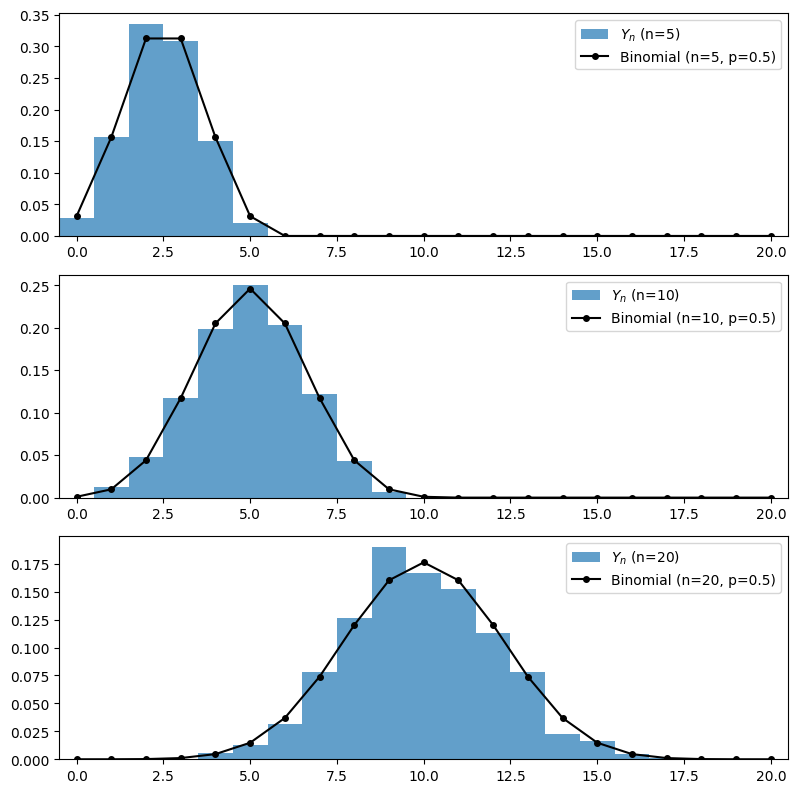

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

for ax, n in zip(axes, [5, 10, 20]):
    # Simulate random binary variables with mean 0.5
    X = (np.random.rand(1000, n) < 0.5).astype(int)
    Y = X.sum(axis=1)

    k = np.arange(0, 21)
    ax.hist(Y, bins=np.arange(-0.5, 21.5, 1), density=True, alpha=0.7, label=f"$Y_n$ (n={n})")
    ax.plot(k, stats.binom.pmf(k, n, 0.5), "ko-", markersize=4, label=f"Binomial (n={n}, p=0.5)")
    ax.legend(loc="upper right")
    ax.set_xlim(-0.5, 20.5)

plt.tight_layout()
plt.show()

Let $\overline{X_n} = Y_n/n$ be the sample mean. According to the CLT, the distribution of $\sqrt{n} (\overline{X_n} - 1/2)$ approaches the normal distribution of zero mean and variance $1/4$.

The plot below shows the comparison. The fit gets better very quickly as $n$ increases.

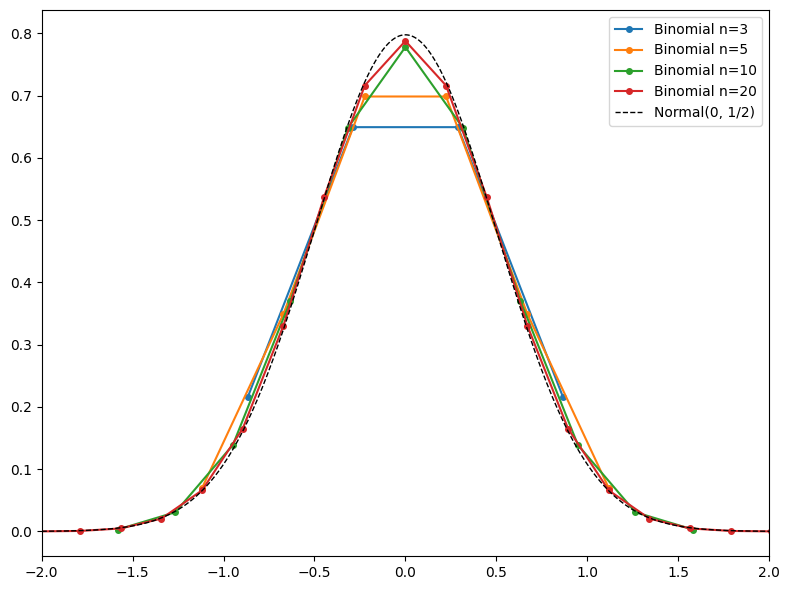

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for n in [3, 5, 10, 20]:
    Y = np.arange(0, n + 1)
    # Rescaled variable: sqrt(n) * (Y/n - 1/2)
    x_rescaled = np.sqrt(n) * (Y / n - 0.5)
    # Rescaled PDF: sqrt(n) * Binomial_pmf
    y_rescaled = np.sqrt(n) * stats.binom.pmf(Y, n, 0.5)
    ax.plot(x_rescaled, y_rescaled, "o-", markersize=4, label=f"Binomial n={n}")

# Normal distribution with mean 0, std 0.5
x_norm = np.linspace(-2, 2, 400)
ax.plot(x_norm, stats.norm.pdf(x_norm, 0, 0.5), "k--", linewidth=1, label="Normal(0, 1/2)")

ax.set_xlim(-2, 2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()